In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import numpy as np 
import h5ify 
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import importlib
import json

import sys
sys.path.append('/home/kgk3/tdinf/tdinf/')
from tdinf import group_postprocess, utils, run_sampler

importlib.reload(group_postprocess)
importlib.reload(run_sampler)

<module 'tdinf.run_sampler' from '/home/kgk3/tdinf/tdinf/run_sampler.py'>

### Load likelihood manager

In [4]:
 # Get likelihood manager
# run = 'output'
# data = group_postprocess.load_run_settings_from_directory(
#     'output/'+run,
data = group_postprocess.load_run_settings_from_directory('output_GW241110_260706_ST4_20k_-0p1_-0p05_-0p025_0', filename_dict={'full':'full_0.0seconds'})
lm = data['runs']['full']['likelihood_manager']

/home/kgk3/tdinf/tdinf/utils/likelihood.py:508: UserWarning: --waveform-kwargs is only supported for gwsignal approximants;ignoring for SpinTaylorT4 which uses the lal interface
  warnings.warn(f"--waveform-kwargs is only supported for gwsignal approximants;"
/home/kgk3/tdinf/tdinf/utils/likelihood.py:508: UserWarning: --waveform-kwargs is only supported for gwsignal approximants;ignoring for SpinTaylorT4 which uses the lal interface
  warnings.warn(f"--waveform-kwargs is only supported for gwsignal approximants;"
/home/kgk3/tdinf/tdinf/utils/likelihood.py:508: UserWarning: --waveform-kwargs is only supported for gwsignal approximants;ignoring for SpinTaylorT4 which uses the lal interface
  warnings.warn(f"--waveform-kwargs is only supported for gwsignal approximants;"


### Load FD posterior and get maxL reconstruction

In [5]:
# get reference parameters
FD_posterior = h5ify.load('GW241110_input_data/GW241110_124123-combined_PEDataRelease.h5')['C00:SEOBNRv5PHM']['posterior_samples']

# get maxL
imax = np.argmax(FD_posterior['log_likelihood'])
reference_parameters_ = FD_posterior[imax]
reference_parameters = {k: reference_parameters_[k] for k in reference_parameters_.dtype.names}

In [12]:
# Get injection
reference_parameters_transformed = run_sampler.modify_parameters(reference_parameters, data['runs']['full']['args'])
injection_dict = lm.waveform_manager.get_projected_waveform(
    reference_parameters_transformed,
    lm.ifos,
    lm.time_dict,
    lm.f22_start, 
    lm.f_ref
)
# Whiten injection
injection_dict_whitened = {ifo : utils.whitenData(
    injection_dict[ifo], 
    lm.time_dict[ifo],
    lm.conditioned_psd_dict[ifo][:, 1], 
    lm.conditioned_psd_dict[ifo][:, 0]
) for ifo in lm.ifos}

In [16]:
print(lm.f22_start)

20.0


In [13]:
# Get detector delay times 
dt_dict = lm.waveform_manager.antenna_and_time_manager.compute_time_delay_dict(
    data['runs']['full']['kwargs']['right_ascension'], 
    data['runs']['full']['kwargs']['declination'], 
    lm.reference_time, 
    lm.ifos
)

### Cumulative SNR check

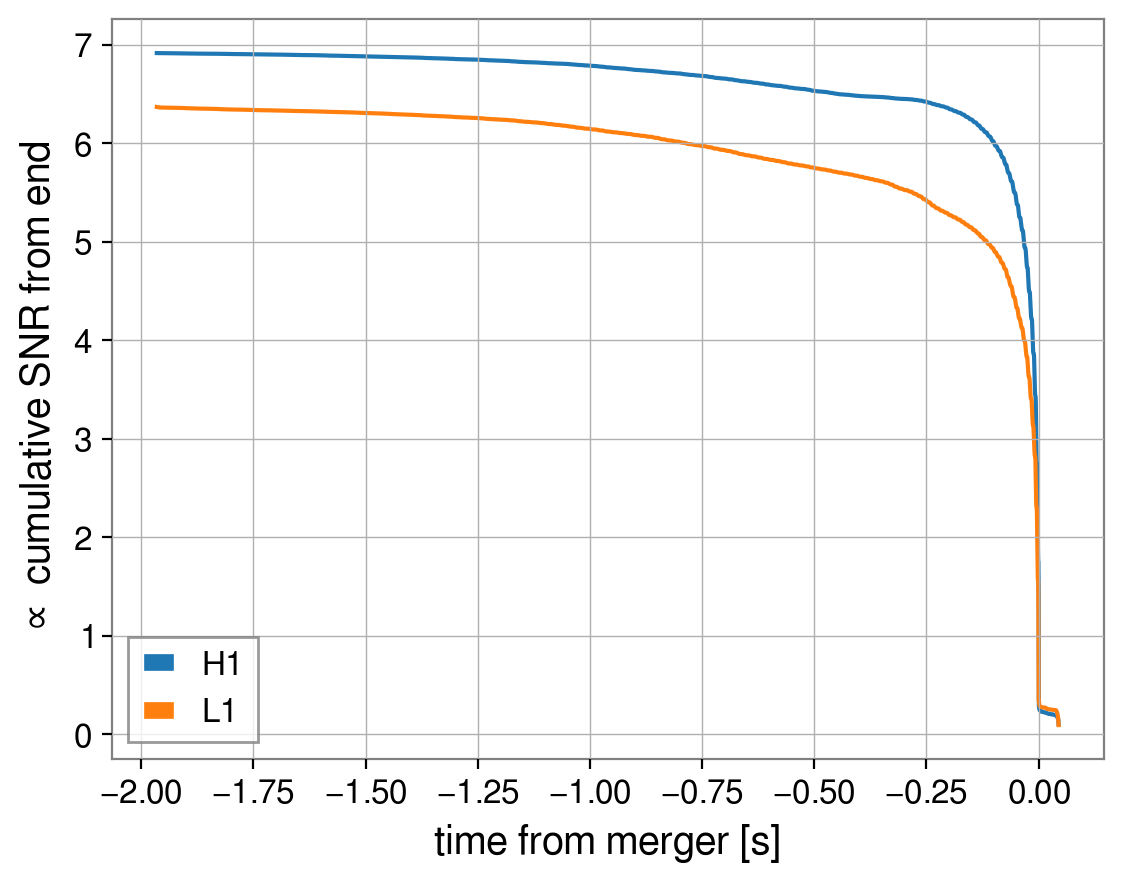

In [14]:
plt.plot()
for ifo in lm.ifos:
    
    times_det = lm.time_dict[ifo] - lm.reference_time - dt_dict[ifo]
    cum_snr = np.sqrt(np.cumsum(injection_dict_whitened[ifo][::-1]**2))
    
    plt.plot(times_det[::-1], cum_snr, label=ifo)
    
plt.legend()
plt.ylabel('$\propto$ cumulative SNR from end')
plt.xlabel('time from merger [s]')
plt.show()

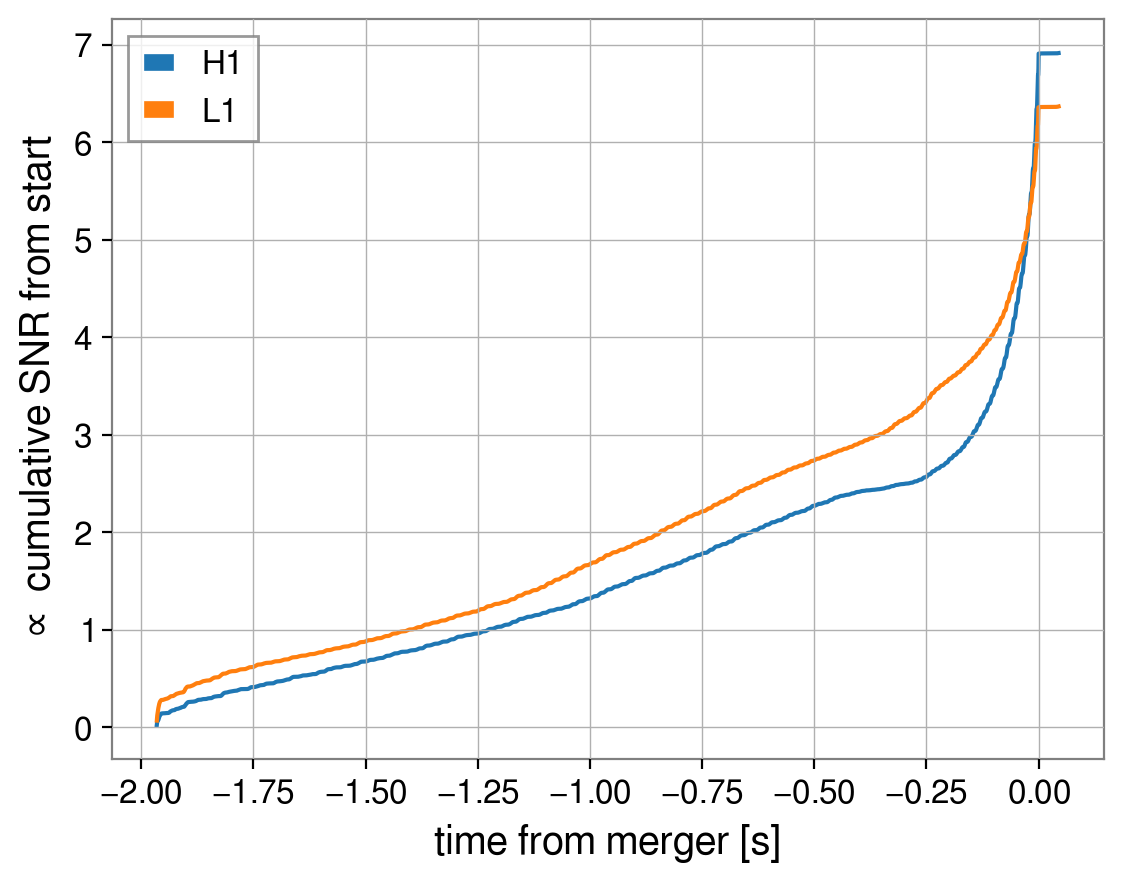

In [15]:
plt.plot()
for ifo in lm.ifos:
    
    times_det = lm.time_dict[ifo] - lm.reference_time - dt_dict[ifo]
    cum_snr = np.sqrt(np.cumsum(injection_dict_whitened[ifo]**2))
    
    plt.plot(times_det, cum_snr, label=ifo)

plt.legend()
plt.ylabel('$\propto$ cumulative SNR from start')
plt.xlabel('time from merger [s]')
plt.show()